In [4]:
%pip install nltk -q

In [5]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from math import log, sqrt

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Read file TED commnent in youtube video
df_0 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Đồ án KHDL/ted_comment.csv")

df = df_0.dropna()

df.head(10)

,video_id,author,comment,published_at,like_count
0,NWvXyobH9fg,@BravoMentorianaAmerica,..\nAnd there are still a lot of people ungry ...,2021-05-06T15:48:29Z,0
1,NWvXyobH9fg,@sinsonsojan6270,The future is very amazing 😎,2021-01-24T14:50:52Z,0
2,NWvXyobH9fg,@taticanellinha,In 16 days we'll be in 2021... It's been 13 ye...,2020-12-14T17:37:44Z,2
3,NWvXyobH9fg,@stevenkawleski3269,And 11 years later... still nothing.,2020-05-06T05:13:26Z,1
4,NWvXyobH9fg,@오이-d2i,??,2019-03-09T05:41:04Z,1
5,NWvXyobH9fg,@captainanopheles4307,I wonder why the less confident speakers think...,2017-08-01T01:14:47Z,0
6,NWvXyobH9fg,@coffeefish,"Wow, she looks like a complete fool.",2017-02-18T12:07:52Z,1
7,NWvXyobH9fg,@תמרנהרי-ג5מ,יפה מה,2017-02-09T14:10:11Z,0
8,NWvXyobH9fg,@TehMorbidAtheist,There is no other life in the universe.,2015-03-26T22:54:26Z,2
9,NWvXyobH9fg,@EpicAMV911,Did she just call sputnik inferior? \n\nReally...,2014-10-15T13:45:12Z,0


In [8]:
# Tạo dataFrame cho bộ dữ liệu
data = pd.DataFrame(df, columns =['comment'])
data

,comment
0,..\nAnd there are still a lot of people ungry ...
1,The future is very amazing 😎
2,In 16 days we'll be in 2021... It's been 13 ye...
3,And 11 years later... still nothing.
4,??
...,...
959906,"I saw the cover picture sexy, so I came to wat..."
959907,i just have to say.. she is sooo beautiful!
959908,Just imagine the heights we could reach with 7...
959909,"She didn't say anything we don't already know,..."


**Trực quan hóa các từ có trong tập dữ liệu**

In [9]:
# Hàm đếm từ, chia theo khoảng trắng
def word_count(sentence):
    return len(sentence.split())

data['word count'] = data['comment'].apply(word_count)
data['word count'].describe()

,word count
count,958684.000000
mean,30.956824
std,52.997878
min,0.000000
25%,7.000000
50%,15.000000
75%,35.000000
max,1928.000000


In [10]:
import collections
all_words = []
for line in list(data['comment']): #Chia chuỗi thành các đơn từ
    words = line.split()
    for word in words:
        all_words.append(word.lower())

collections.Counter(all_words).most_common(10)#In ra 10 từ phổ biến nhất

[('the', 1181109),
 ('to', 796842),
 ('and', 724603),
 ('a', 600674),
 ('of', 586535),
 ('is', 554505),
 ('i', 478602),
 ('in', 380085),
 ('that', 362232),
 ('you', 312671)]

Text(0.5, 0, 'Word Rank')

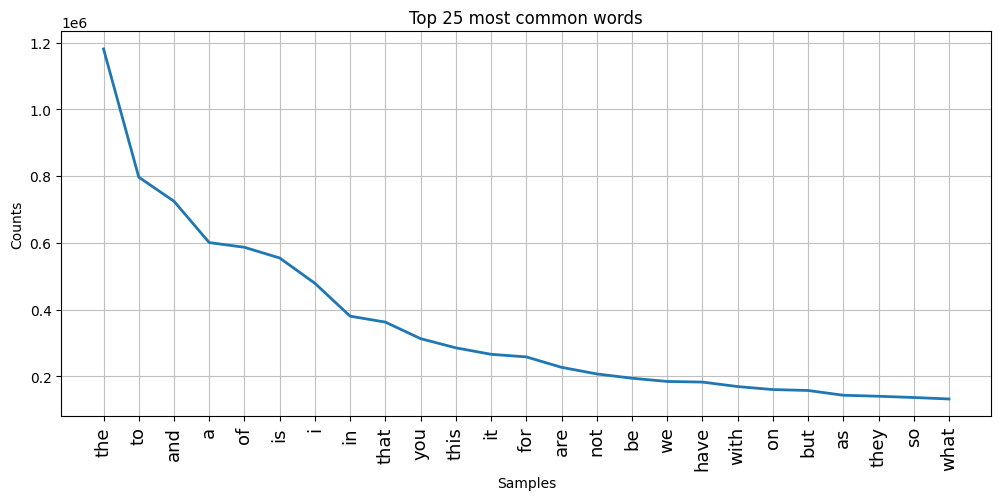

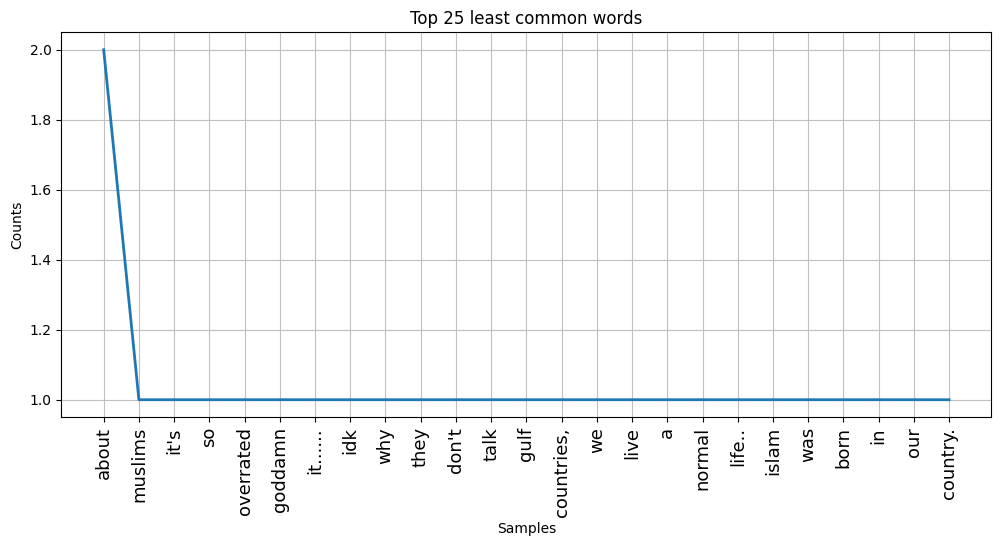

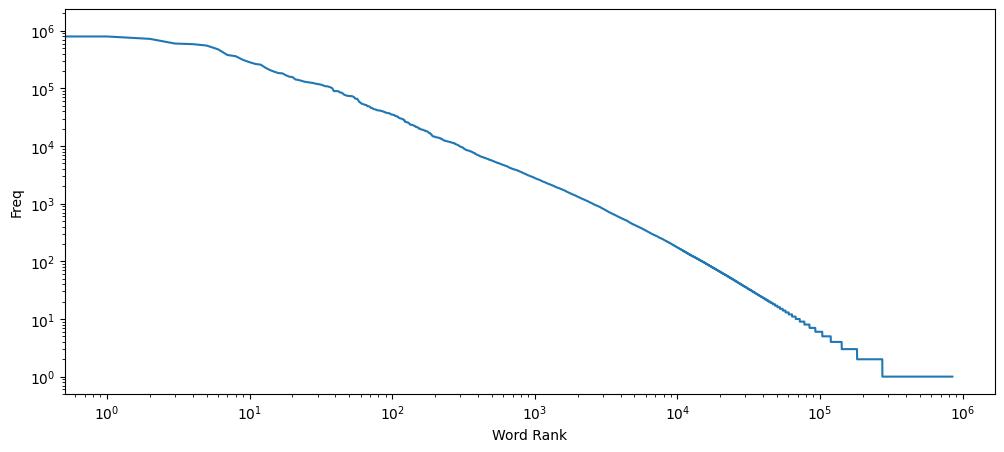

In [11]:
# plot word frequency distribution of most common words
plt.figure(figsize=(12,5))
plt.title('Top 25 most common words')
plt.xticks(fontsize=13, rotation=90)
fd = nltk.FreqDist(all_words)
fd.plot(25,cumulative=False)

# plot word frequency distribution of least common words
plt.figure(figsize=(12,5))
plt.title('Top 25 least common words')
plt.xticks(fontsize=13, rotation=90)
fd = nltk.FreqDist(all_words[-26:])
fd.plot(cumulative=False)

# log-log plot
word_counts = sorted(collections.Counter(all_words).values(), reverse=True)
plt.figure(figsize=(12,5))
plt.loglog(word_counts, linestyle='-', linewidth=1.5)
plt.ylabel("Freq")
plt.xlabel("Word Rank")

**Tiền xử lý dữ liệu**

In [12]:
import string
def processComment(text):
    # Remove HTML special entities (e.g. &amp;)
    text = re.sub(r'\&\w*;', '', text)
    #Convert @username to AT_USER
    text = re.sub('@[^\s]+','',text)
    # Remove tickers
    text = re.sub(r'\$\w*', '', text)
    # To lowercase
    text = text.lower()
    # Remove hyperlinks
    text = re.sub(r'https?:\/\/.*\/\w*', '', text)
    # Remove hashtags
    text = re.sub(r'#\w*', '', text)
    # Remove Punctuation and split 's, 't, 've with a space for filter
    text = re.sub(r'['+string.punctuation+']+', ' ', text)
    # Remove words with 2 or fewer letters
    text = re.sub(r'\b\w{1,2}\b', '', text)
    # Remove whitespace (including new line characters)
    text = re.sub(r'\s\s+', ' ', text)
    # Remove single space remaining at the front of the text.
    text = text.lstrip(' ')
    # Remove characters beyond Basic Multilingual Plane (BMP) of Unicode:
    text = ''.join(c for c in text if c <= '\uFFFF')
    return text

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1365753971.py:6: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('@[^\s]+','',text)


In [13]:
# clean dataframe's text column
data['text'] = data['comment'].apply(processComment)
# preview some cleaned tweets
data['text'].head()

,text
0,and there are still lot people ungry the stree...
1,the future very amazing
2,days 2021 been years and load money later and ...
3,and years later still nothing
4,


**Lemmatization**

In [14]:
from nltk.stem import WordNetLemmatizer
w_tokenizer=nltk.tokenize.WhitespaceTokenizer()
lemmatizer=WordNetLemmatizer() # Xóa bỏ các hậu tố
def lemmatize_text(text):
    return[lemmatizer.lemmatize(w)for w in w_tokenizer.tokenize(text)]

In [15]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [16]:
data['lemm_cmt']=data.text.apply(lemmatize_text)
data['temp_cmt']=[' '.join(map(str, l))for l in data['lemm_cmt']]

data.head()

,comment,word count,text,lemm_cmt,temp_cmt
0,..\nAnd there are still a lot of people ungry ...,15,and there are still lot people ungry the stree...,"[and, there, are, still, lot, people, ungry, t...",and there are still lot people ungry the stree...
1,The future is very amazing 😎,6,the future very amazing,"[the, future, very, amazing]",the future very amazing
2,In 16 days we'll be in 2021... It's been 13 ye...,22,days 2021 been years and load money later and ...,"[day, 2021, been, year, and, load, money, late...",day 2021 been year and load money later and st...
3,And 11 years later... still nothing.,6,and years later still nothing,"[and, year, later, still, nothing]",and year later still nothing
4,??,1,,[],


In [17]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stopwords_english = set(stopwords.words('english'))  # Sử dụng set thay vì list
print (stopwords_english)

{'yourselves', 'weren', 'as', "it'll", 'who', 'had', 'why', "wasn't", 'which', 'of', 'under', 'wasn', "you're", 'when', "we're", "isn't", 'doesn', 'each', 'does', 'now', "that'll", 'is', 'isn', 'on', 'that', "doesn't", 'few', 'the', 'between', 'she', "hadn't", 'are', 'shouldn', 's', 'this', 'haven', 'off', 'hers', 'too', "they've", 'i', 'any', 'again', "haven't", "he'd", "i'll", "mustn't", "shan't", 'against', "don't", "we'd", 'more', "shouldn't", 'did', 'nor', 'while', 'have', 'no', 'ours', "hasn't", 'just', 're', 'very', "i'd", 'wouldn', 'up', "you'll", 'o', 'these', 'a', "they're", 'don', 'itself', "aren't", 'before', 'not', 'will', 'such', 'him', 'above', "he's", 'ma', 'or', 'theirs', "i've", 'then', 'there', 'himself', 'with', "didn't", 'yours', 'by', 'if', 'our', 'down', 'below', 'from', 'most', 'those', "she'll", 'herself', 'their', 'couldn', 'me', 'until', 'its', 'in', 'into', 'to', 'has', 'what', 'themselves', 'your', 'through', 'yourself', 'doing', "needn't", 'out', 'having',

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
from textblob import Word
def text_process(raw_text):
    # Check characters to see if they are in punctuation
    nopunc = [char for char in list(raw_text) if char not in string.punctuation]
    # Join the characters again to form the string.
    nopunc = ''.join(nopunc)

    # remove all stopwords
    return [word for word in nopunc.lower().split() if word.lower() not in stopwords_english]

# Các từ bạn muốn thêm vào stop words
additional_stop_words = [
    # === LỖI KỸ THUẬT / CẮT CỤT / NHIỄU ===
    'wa', 'ha', '’', 'doe', 'don’', 'dont', 'medium',

    # === FILLER WORDS PHỔ BIẾN TRONG COMMENT ===
    'like', 'one', 'would', 'get', 'make', 'need', 'talk', 'thing', 'want', 'even', 'much',
    'see', 'say', 'know', 'think', 'year', 'way', 'many', 'also', 'never', 'could', 'well',
    'take', 'still', 'time', 'really', 'right', 'work', 'going', 'day', 'something', 'look',
    'better', 'believe', 'come', 'feel', 'every', 'life', 'world', 'does', 'change', 'first',
    'said', 'new', 'always', 'back', 'point', 'person', 'nothing', 'real', 'give', 'help',
    'use', 'mean', 'ever', 'let', 'lot', 'stop', 'without', 'everything', 'actually',
    'everyone', 'find', 'someone', 'got', 'end', 'keep', 'wrong', 'anything', 'another',
    'bad', 'long', 'true', 'part', 'tell', 'may', 'anyone', 'already', 'around', 'comment',
    'big', 'tho', 'idk', 'tbh', 'fr', 'rn', 'btw', 'ikr',

    # === YOUTUBE-SPECIFIC & SLANG ===
    'video', 'youtube', 'channel', 'subscribe', 'sub', 'pls', 'please', 'bro', 'dude',
    'omg', 'lmao', 'lol', 'xd', 'bruh', 'fyp', 'algorithm', 'content', 'watch',
    'watching', 'watched', 'views', 'view', 'click', 'clicked', 'here', 'link',

    # === FILLER VERB / HÀNH ĐỘNG CHUNG ===
    'made', 'thought', 'understand', 'live', 'making', 'try', 'done', 'show', 'become',
    'getting', 'put', 'trying', 'used', 'start', 'away', 'using', 'living', 'thinking',
    'cause', 'seen', 'call', 'hear', 'based', 'called', 'saying', 'create', 'created',
    'listen', 'cannot',

    # === FILLER BIỂU CẢM / LIÊN TỪ / TRẠNG THÁI ===
    'talking', 'sure', 'yes', 'yet', 'instead', 'might', 'able', 'wow', 'kind', 'else',
    'others', 'self', 'though', 'seems', 'agree', 'wish', 'nice',

    # === LƯỢNG TỪ / SỐ / THỜI GIAN / KHÔNG GIAN ===
    'less', 'little', 'two', 'far', 'left', 'whole', 'today', 'ago', 'last', 'next', 'hand',
    'level', 'high', 'least', 'side',

    # === ĐỘNG TỪ / TRẠNG TỪ / META ===
    'sound', 'read', 'hard', 'enough', 'care', 'hope', 'word', 'place', 'answer', 'example', 'sense',

    # === KÝ HIỆU / THỪA ===
    'etc', 'thanks', "000"
]

# Thêm các từ vào stop words
stopwords_english.update(additional_stop_words)

def remove_words(word_list):
    # remove = ['i','me','my','flight','hour','minute','wa','airline','bag','plane','cancelled','myself','we','our','ours','ourselves','you',"you're","you've","you'll","you'd",'your','yours','yourself','yourselves','he','him','his','himself','she',"she's",'her','hers','herself','it',"it's",'its','itself','they','them','their','theirs','themselves','what','which','who','whom','this','that',"that'll",'these','those','am','is','are','was','were','be','been','being','have','has','had','having','do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while','of','at','by','for','with','about','against','between','into','through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further','then','once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','...','“','”','’','...']
    remove = stopwords_english
    return [w for w in word_list if w not in remove]

In [19]:
# tokenize message column and create a column for tokens
data['temp']=data['temp_cmt'].apply(text_process)
data['tokens']=data['temp'].apply(remove_words)

data[['text','temp_cmt','temp','tokens']]

,text,temp_cmt,temp,tokens
0,and there are still lot people ungry the stree...,and there are still lot people ungry the stree...,"[people, ungry, street, earth]","[people, ungry, street, earth]"
1,the future very amazing,the future very amazing,"[future, amazing]","[future, amazing]"
2,days 2021 been years and load money later and ...,day 2021 been year and load money later and st...,"[2021, load, money, later, nada, zero]","[2021, load, money, later, nada, zero]"
3,and years later still nothing,and year later still nothing,[later],[later]
4,,,[],[]
...,...,...,...,...
959906,saw the cover picture sexy came watch but diss...,saw the cover picture sexy came watch but diss...,"[saw, cover, picture, sexy, came, disspointed,...","[saw, cover, picture, sexy, came, disspointed,..."
959907,just have say she sooo beautiful,just have say she sooo beautiful,"[sooo, beautiful]","[sooo, beautiful]"
959908,just imagine the heights could reach with bill...,just imagine the height could reach with billi...,"[imagine, height, reach, billion, educated, mind]","[imagine, height, reach, billion, educated, mind]"
959909,she didn say anything don already know and she...,she didn say anything don already know and she...,"[explore, root, problem, case, suggest, girl, ...","[explore, root, problem, case, suggest, girl, ..."


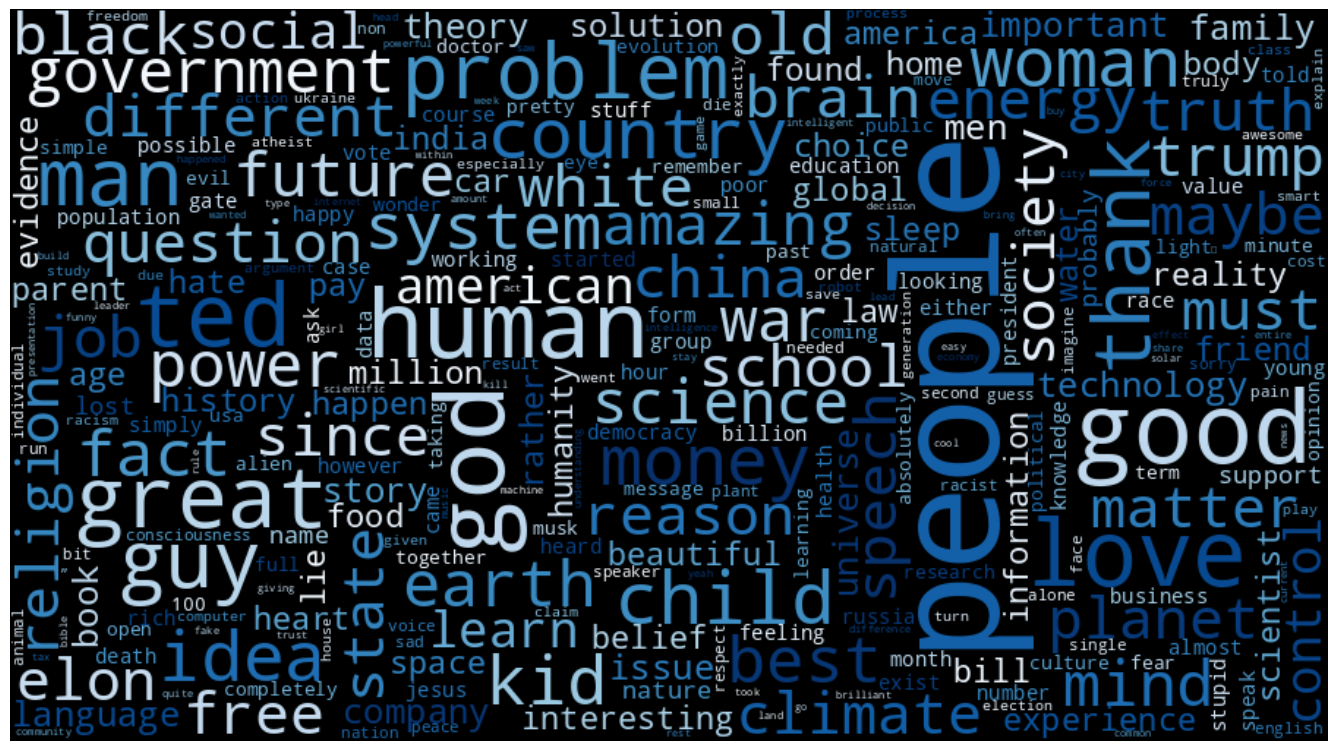

In [20]:
# split sentences to get individual words
all_words = []
for line in data['temp']:
    all_words.extend(line)


# create a word frequency dictionary
wordfreq = collections.Counter(all_words)# draw a Word Cloud with word frequencies
wordcloud = WordCloud(width=900,
                      height=500,
                      max_words=300,
                      max_font_size=100,
                      relative_scaling=0.5,
                      colormap='Blues',
                      normalize_plurals=True).generate_from_frequencies(wordfreq)
plt.figure(figsize=(17,14))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## TỔNG QUAN CHỦ ĐỀ TRONG WORD CLOUD

| Chủ đề | Từ khóa chính | Tỷ lệ ước tính | Mô tả ngắn |
|--------|-------------|:-------------:|-----------|
| **1. TED Talks & Khoa học - Tương lai** | `ted`, `science`, `future`, `brain`, `technology`, `universe`, `theory`, `energy`, `space`, `scientist` | **~35%** | **RÕ NHẤT & MẠNH NHẤT** |
| **2. Chính trị - Xã hội - Quyền lực** | `government`, `country`, `china`, `america`, `trump`, `state`, `american`, `control`, `power`, `war`, `law`, `bill` | **~25%** | Rất nóng |
| **3. Con người - Tâm lý - Cảm xúc** | `people`, `human`, `love`, `mind`, `heart`, `good`, `great`, `amazing`, `beautiful`, `hate`, `lie`, `belief`, `experience`, `reality` | **~20%** | Triết lý + cảm xúc |
| **4. Môi trường - Sinh tồn - Toàn cầu** | `climate`, `earth`, `planet`, `water`, `food`, `global`, `energy` | **~10%** | Nổi bật |
| **5. Gia đình - Giáo dục - Cuộc sống** | `child`, `kid`, `family`, `school`, `parent`, `home`, `job`, `money`, `friend`, `story`, `language`, `book` | **~10%** | Gần gũi |

> **Nguồn**: Phân tích từ top 100 từ tần suất cao nhất trong bình luận YouTube (sau khi loại stop words).

In [21]:
import collections
all_words = []
for line in list(data['tokens']):
    for word in line:
        all_words.append(word.lower())

collections.Counter(all_words).most_common(10)

[('people', 143706),
 ('good', 51841),
 ('god', 47441),
 ('human', 45262),
 ('love', 44527),
 ('ted', 39391),
 ('great', 37538),
 ('man', 34000),
 ('guy', 32344),
 ('thank', 32043)]

Text(0.5, 1.0, 'log-log plot of words frequency')

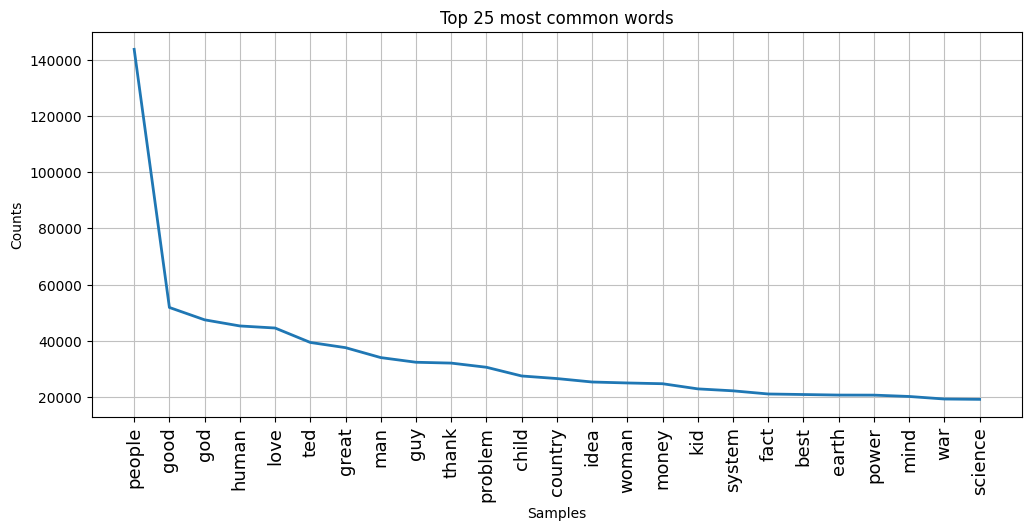

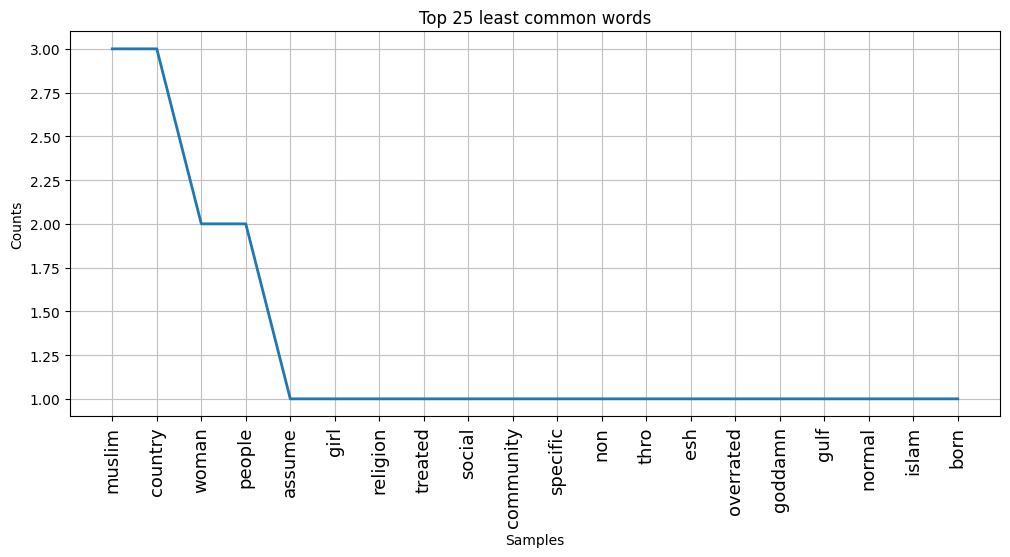

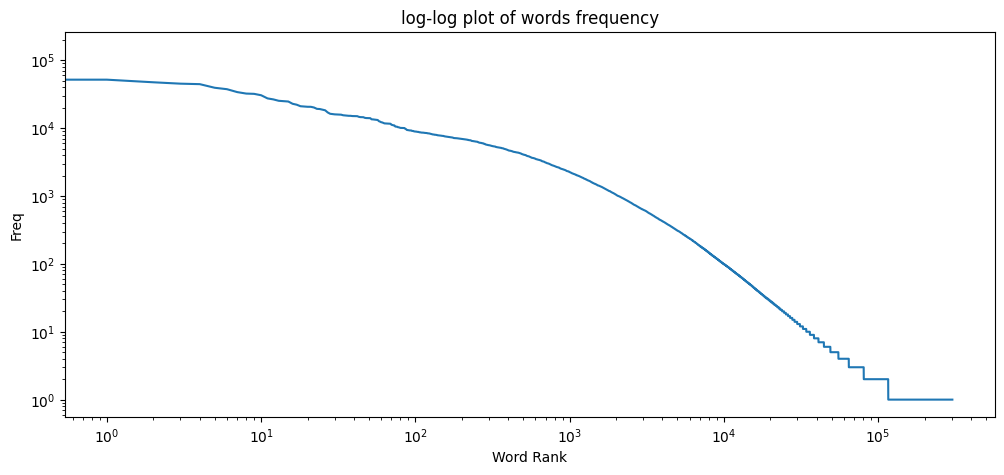

In [22]:
#plot word frequency distribution of most common words
plt.figure(figsize=(12,5))
plt.title('Top 25 most common words')
plt.xticks(fontsize=13, rotation=90)
fd = nltk.FreqDist(all_words)
fd.plot(25,cumulative=False)

# plot word frequency distribution of least common words
plt.figure(figsize=(12,5))
plt.title('Top 25 least common words')
plt.xticks(fontsize=13, rotation=90)
fd = nltk.FreqDist(all_words[-26:])
fd.plot(cumulative=False)

# log-log plot
word_counts = sorted(collections.Counter(all_words).values(), reverse=True)
plt.figure(figsize=(12,5))
plt.loglog(word_counts, linestyle='-', linewidth=1.5)
plt.ylabel("Freq")
plt.xlabel("Word Rank")
plt.title('log-log plot of words frequency')

In [23]:
data.head()

,comment,word count,text,lemm_cmt,temp_cmt,temp,tokens
0,..\nAnd there are still a lot of people ungry ...,15,and there are still lot people ungry the stree...,"[and, there, are, still, lot, people, ungry, t...",and there are still lot people ungry the stree...,"[people, ungry, street, earth]","[people, ungry, street, earth]"
1,The future is very amazing 😎,6,the future very amazing,"[the, future, very, amazing]",the future very amazing,"[future, amazing]","[future, amazing]"
2,In 16 days we'll be in 2021... It's been 13 ye...,22,days 2021 been years and load money later and ...,"[day, 2021, been, year, and, load, money, late...",day 2021 been year and load money later and st...,"[2021, load, money, later, nada, zero]","[2021, load, money, later, nada, zero]"
3,And 11 years later... still nothing.,6,and years later still nothing,"[and, year, later, still, nothing]",and year later still nothing,[later],[later]
4,??,1,,[],,[],[]


In [24]:
data['clean_cmt'] = [' '.join(map(str, l)) for l in data['tokens']]
data=data.drop(columns=['lemm_cmt','text','temp','temp_cmt', 'word count'])
data.head()

,comment,tokens,clean_cmt
0,..\nAnd there are still a lot of people ungry ...,"[people, ungry, street, earth]",people ungry street earth
1,The future is very amazing 😎,"[future, amazing]",future amazing
2,In 16 days we'll be in 2021... It's been 13 ye...,"[2021, load, money, later, nada, zero]",2021 load money later nada zero
3,And 11 years later... still nothing.,[later],later
4,??,[],


In [25]:
data.head()

,comment,tokens,clean_cmt
0,..\nAnd there are still a lot of people ungry ...,"[people, ungry, street, earth]",people ungry street earth
1,The future is very amazing 😎,"[future, amazing]",future amazing
2,In 16 days we'll be in 2021... It's been 13 ye...,"[2021, load, money, later, nada, zero]",2021 load money later nada zero
3,And 11 years later... still nothing.,[later],later
4,??,[],


In [26]:
from nltk import bigrams
terms_bigram = [list(bigrams(tweet)) for tweet in data.tokens]
terms_bigram[0]

[('people', 'ungry'), ('ungry', 'street'), ('street', 'earth')]

In [27]:
import itertools
# Flatten list of bigrams in clean tweets
# In tất cả các giá trị có trong terms_bigram có thể lặp lại lần lượt
bigrams = list(itertools.chain(*terms_bigram))
# Create counter of words in clean bigrams
bigram_counts = collections.Counter(bigrams)
bigram_counts.most_common(25)

[(('elon', 'musk'), 5158),
 (('bill', 'gate'), 4960),
 (('india', 'india'), 3625),
 (('global', 'warming'), 3159),
 (('fossil', 'fuel'), 2793),
 (('god', 'bless'), 2741),
 (('united', 'state'), 2715),
 (('black', 'hole'), 2607),
 (('white', 'people'), 2606),
 (('civil', 'war'), 2085),
 (('jesus', 'christ'), 2063),
 (('best', 'ted'), 2003),
 (('black', 'people'), 1835),
 (('binod', 'binod'), 1773),
 (('thank', 'sharing'), 1752),
 (('good', 'luck'), 1674),
 (('mental', 'health'), 1655),
 (('people', 'people'), 1629),
 (('young', 'people'), 1530),
 (('free', 'speech'), 1459),
 (('nope', 'nope'), 1450),
 (('solve', 'problem'), 1447),
 (('god', 'god'), 1414),
 (('social', 'security'), 1394),
 (('solar', 'system'), 1375)]

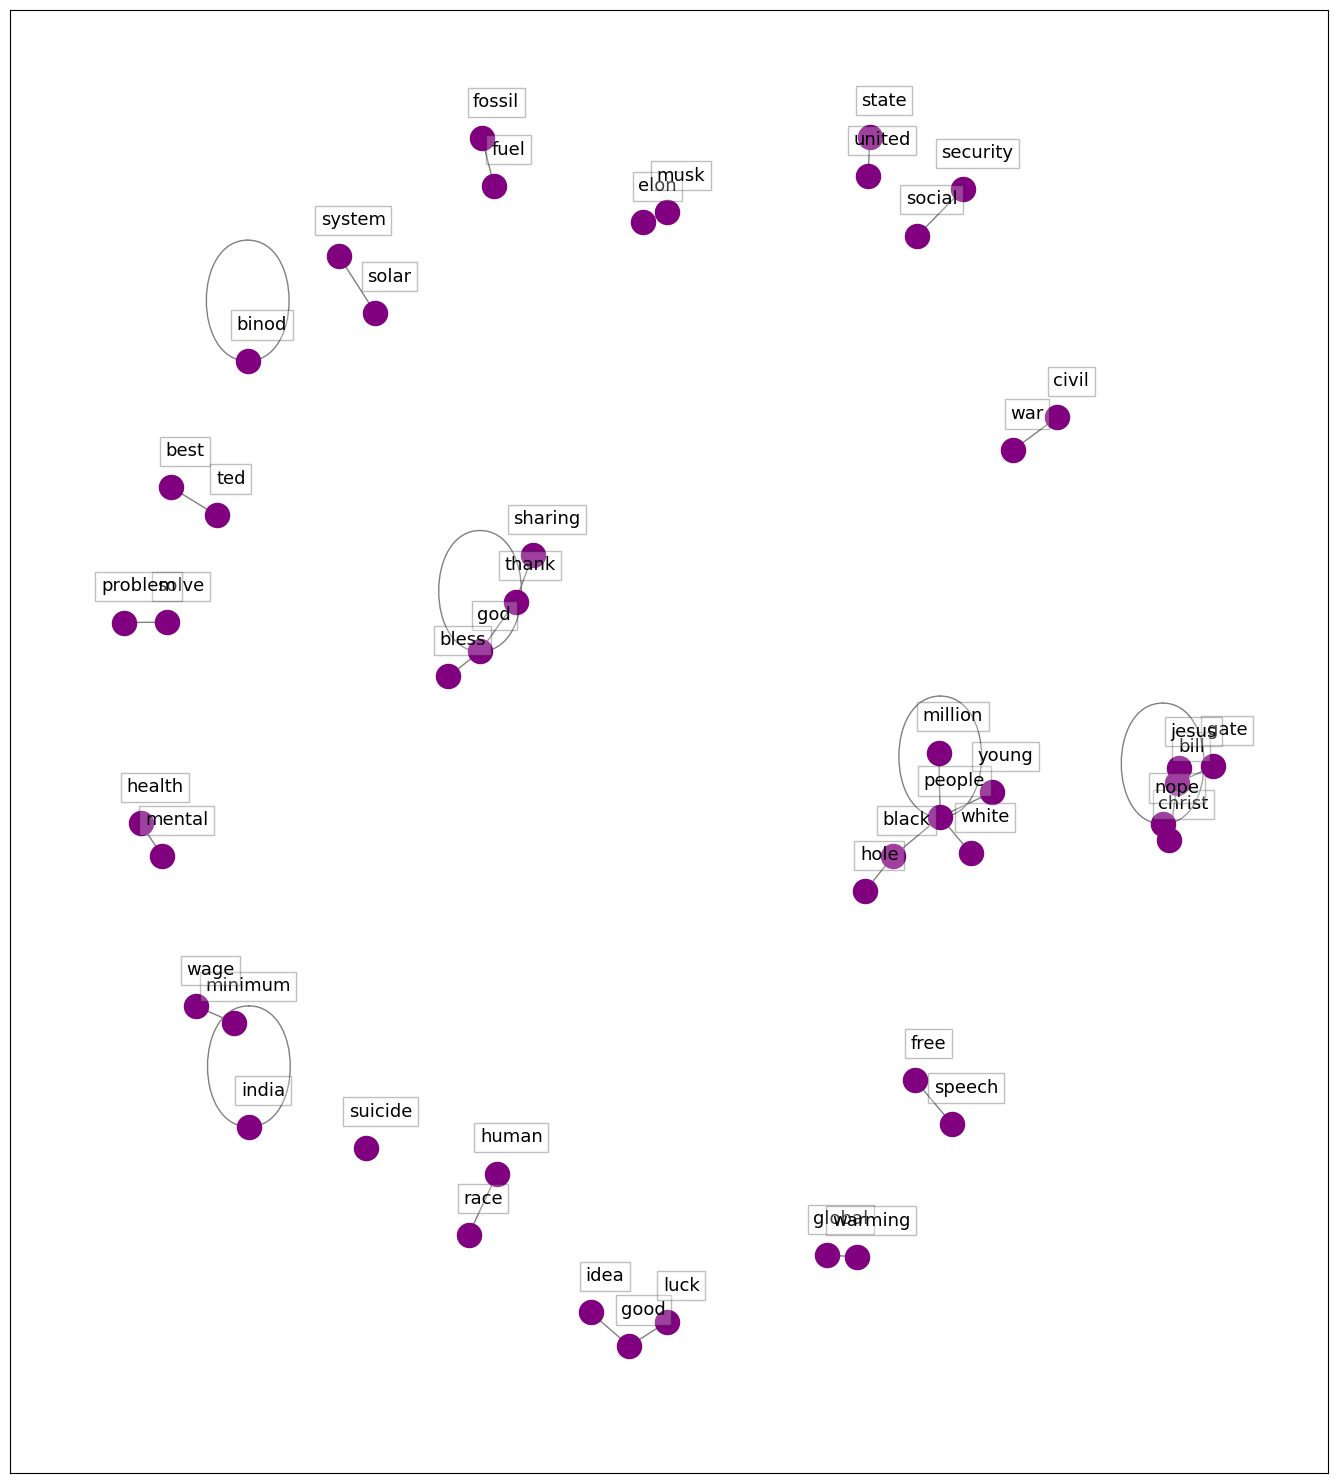

In [28]:
import networkx as nx
bigram_df = pd.DataFrame(bigram_counts.most_common(30),columns=['bigram', 'count'])

# Create dictionary of bigrams and their counts
d = bigram_df.set_index('bigram').T.to_dict('records')

# Create network plot # Tạo một biểu đồ trống
G = nx.Graph()

# Create connections between nodes
for k, v in d[0].items():
    G.add_edge(k[0], k[1], weight=(v * 10))

G.add_node("suicide", weight=100) # Thêm node sad tỏng G

fig, ax = plt.subplots(figsize=(17, 19))

pos = nx.spring_layout(G, k=5) # tanawmg khoảng cách giữa các node là 2

# Plot networks
nx.draw_networkx(G, pos,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# Create offset labels
for key, value in pos.items():
    x, y = value[0]+0.025, value[1]+0.05
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='white', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.show()

Ý nghĩa từ biểu đồ:

Biểu đồ này rất hữu ích để nhanh chóng xác định các cụm từ quan trọng và chủ đề nổi bật trong dữ liệu bình luận. Chúng ta có thể suy luận:

Các nhân vật công chúng: Sự hiện diện của ('elon', 'musk') và ('bill', 'gate') cho thấy các cuộc thảo luận xoay quanh những nhân vật công nghệ và các ý tưởng của họ là phổ biến.<br>
Chủ đề môi trường: ('global', 'warming') và ('fossil', 'fuel') chỉ ra rằng biến đổi khí hậu và năng lượng là những chủ đề được quan tâm.<br>
Chủ đề xã hội/chính trị: ('united', 'state'), ('civil', 'war'), ('black', 'hole'), ('white', 'people'), ('black', 'people') cho thấy có những cuộc đối thoại về chính trị, xã hội, chủng tộc và cả khoa học.<br>
Các cụm từ lặp lại/memes: ('india', 'india') hoặc ('binod', 'binod') có thể là những cụm từ lặp lại, những meme hoặc lỗi chính tả phổ biến trong các bình luận.<br>
Nhìn chung, biểu đồ mạng cung cấp một cái nhìn tổng quan trực quan về các mối quan hệ từ ngữ mạnh mẽ nhất trong dữ liệu, giúp khám phá các chủ đề chính mà không cần phải đọc qua hàng ngàn bình luận.

Sentiment Analysis

In [29]:
from textblob import TextBlob
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [30]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# assuming your cleaned data is in a DataFrame called 'df' and the text is in a column called 'text'
# initialize the VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# apply the VADER sentiment analyzer to each sentence in the 'text' column and create a new column called 'sentiment'
data['sentiment'] = data['clean_cmt'].apply(lambda x: sid.polarity_scores(x)['compound'])

# classify each sentence as positive, negative or neutral based on the 'sentiment' score
data['sentiment_class'] = pd.cut(data['sentiment'], bins=[-1, -0.1, 0.1, 1], labels=['negative', 'neutral', 'positive'])

# print the first 10 rows of the DataFrame
data.head(10)


,comment,tokens,clean_cmt,sentiment,sentiment_class
0,..\nAnd there are still a lot of people ungry ...,"[people, ungry, street, earth]",people ungry street earth,0.0000,neutral
1,The future is very amazing 😎,"[future, amazing]",future amazing,0.5859,positive
2,In 16 days we'll be in 2021... It's been 13 ye...,"[2021, load, money, later, nada, zero]",2021 load money later nada zero,0.0000,neutral
3,And 11 years later... still nothing.,[later],later,0.0000,neutral
4,??,[],,0.0000,neutral
5,I wonder why the less confident speakers think...,"[wonder, confident, speaker, wasting, bio, mea...",wonder confident speaker wasting bio meat reme...,-0.1027,negative
6,"Wow, she looks like a complete fool.","[complete, fool]",complete fool,-0.4404,negative
7,יפה מה,[יפה],יפה,0.0000,neutral
8,There is no other life in the universe.,[universe],universe,0.0000,neutral
9,Did she just call sputnik inferior? \n\nReally...,"[sputnik, inferior, sputnik, revolutionized, p...",sputnik inferior sputnik revolutionized paved ...,-0.8316,negative


In [31]:
import numpy as np

# Define neutral range
neutral_min = -0.2
neutral_max = 0.2

# Create empty list for sentiment labels
sentiment_labels = []

# Loop through sentiment scores
for score in data.sentiment:
    if score < neutral_min:
        # Sentiment is negative
        sentiment_labels.append(0)
    elif score > neutral_max:
        # Sentiment is positive
        sentiment_labels.append(1)
    else:
        # Sentiment is neutral
        sentiment_labels.append(2)

In [32]:
data['label'] = sentiment_labels
data

,comment,tokens,clean_cmt,sentiment,sentiment_class,label
0,..\nAnd there are still a lot of people ungry ...,"[people, ungry, street, earth]",people ungry street earth,0.0000,neutral,2
1,The future is very amazing 😎,"[future, amazing]",future amazing,0.5859,positive,1
2,In 16 days we'll be in 2021... It's been 13 ye...,"[2021, load, money, later, nada, zero]",2021 load money later nada zero,0.0000,neutral,2
3,And 11 years later... still nothing.,[later],later,0.0000,neutral,2
4,??,[],,0.0000,neutral,2
...,...,...,...,...,...,...
959906,"I saw the cover picture sexy, so I came to wat...","[saw, cover, picture, sexy, came, disspointed,...",saw cover picture sexy came disspointed superf...,0.5267,positive,1
959907,i just have to say.. she is sooo beautiful!,"[sooo, beautiful]",sooo beautiful,0.5994,positive,1
959908,Just imagine the heights we could reach with 7...,"[imagine, height, reach, billion, educated, mind]",imagine height reach billion educated mind,0.0258,neutral,2
959909,"She didn't say anything we don't already know,...","[explore, root, problem, case, suggest, girl, ...",explore root problem case suggest girl opposit...,0.4767,positive,1


In [33]:
#Calculating Negative, Positive, Neutral and Compound values
data[['polarity', 'subjectivity']] = data['clean_cmt'].apply(lambda Text: pd.Series(TextBlob(Text).sentiment))
for index, row in data['clean_cmt'].items():
    score = SentimentIntensityAnalyzer().polarity_scores(row)
    neg = score['neg']
    neu = score['neu']
    pos = score['pos']
    comp = score['compound']
    data.loc[index, 'neg'] = neg
    data.loc[index, 'neu'] = neu
    data.loc[index, 'pos'] = pos
    data.loc[index, 'compound'] = comp
data.head(5)

,comment,tokens,clean_cmt,sentiment,sentiment_class,label,polarity,subjectivity,neg,neu,pos,compound
0,..\nAnd there are still a lot of people ungry ...,"[people, ungry, street, earth]",people ungry street earth,0.0000,neutral,2,0.0,0.0000,0.0,1.000,0.000,0.0000
1,The future is very amazing 😎,"[future, amazing]",future amazing,0.5859,positive,1,0.3,0.5125,0.0,0.208,0.792,0.5859
2,In 16 days we'll be in 2021... It's been 13 ye...,"[2021, load, money, later, nada, zero]",2021 load money later nada zero,0.0000,neutral,2,0.0,0.0000,0.0,1.000,0.000,0.0000
3,And 11 years later... still nothing.,[later],later,0.0000,neutral,2,0.0,0.0000,0.0,1.000,0.000,0.0000
4,??,[],,0.0000,neutral,2,0.0,0.0000,0.0,0.000,0.000,0.0000


In [34]:
data.to_csv("/content/drive/MyDrive/Colab Notebooks/Đồ án KHDL/sentimentanalysis_output.csv", sep=',', encoding='UTF-8')
data.head(5)

,comment,tokens,clean_cmt,sentiment,sentiment_class,label,polarity,subjectivity,neg,neu,pos,compound
0,..\nAnd there are still a lot of people ungry ...,"[people, ungry, street, earth]",people ungry street earth,0.0000,neutral,2,0.0,0.0000,0.0,1.000,0.000,0.0000
1,The future is very amazing 😎,"[future, amazing]",future amazing,0.5859,positive,1,0.3,0.5125,0.0,0.208,0.792,0.5859
2,In 16 days we'll be in 2021... It's been 13 ye...,"[2021, load, money, later, nada, zero]",2021 load money later nada zero,0.0000,neutral,2,0.0,0.0000,0.0,1.000,0.000,0.0000
3,And 11 years later... still nothing.,[later],later,0.0000,neutral,2,0.0,0.0000,0.0,1.000,0.000,0.0000
4,??,[],,0.0000,neutral,2,0.0,0.0000,0.0,0.000,0.000,0.0000


In [35]:
#Creating new data frames for all sentiments (positive, negative and neutral)

df_negative = data[data["sentiment"]=="negative"]
df_positive = data[data["sentiment"]=="positive"]
df_neutral = data[data["sentiment"]=="neutral"]

In [36]:
df_negative.count()

,0
comment,0
tokens,0
clean_cmt,0
sentiment,0
sentiment_class,0
label,0
polarity,0
subjectivity,0
neg,0
neu,0


In [37]:
#Function for count_values_in single columns

def count_values_in_column(data,feature):
    total=data.loc[:,feature].value_counts(dropna=False)
    percentage=round(data.loc[:,feature].value_counts(dropna=False,normalize=True)*100,2)
    return pd.concat([total,percentage],axis=1,keys=['Total','Percentage'])

In [38]:
#Count_values for sentiment
count_values_in_column(data,"label")

,Total,Percentage
label,,
1,365768,38.15
2,362858,37.85
0,230058,24.00


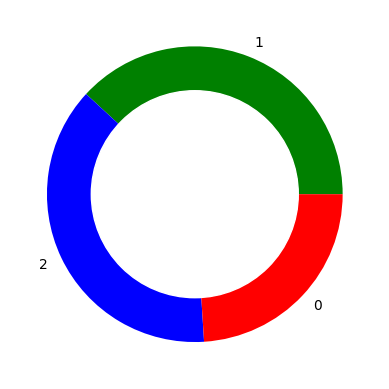

In [39]:
ss# create data for Pie Chart
pichart = count_values_in_column(data,"label")
# names= pc.index
# size=pc["Percentage"]

names= pichart.index
size=pichart["Percentage"]

# Create a circle for the center of the plot
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(size, labels=names, colors=['green','blue','red'])
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()